In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import urllib.request
import os

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
if not os.path.exists("mnist.npz"):
    urllib.request.urlretrieve(url, "mnist.npz")

data = np.load('mnist.npz')

X_train = data['x_train'].reshape(-1, 784) / 255.0
Y_train = data['y_train']
X_test  = data['x_test'].reshape(-1, 784)  / 255.0
Y_test  = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

X_train shape: (60000, 784)
X_test  shape: (10000, 784)


In [4]:
def one_hot_encode(labels, num_classes=10):
    m = len(labels)
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), labels] = 1
    return one_hot

Y_train_oh = one_hot_encode(Y_train)
Y_test_oh  = one_hot_encode(Y_test)

In [5]:
np.random.seed(42)

W1 = np.random.uniform(-0.5, 0.5, (784, 128))
b1 = np.zeros((1, 128))

W2 = np.random.uniform(-0.5, 0.5, (128, 64))
b2 = np.zeros((1, 64))

W3 = np.random.uniform(-0.5, 0.5, (64, 10))
b3 = np.zeros((1, 10))

In [6]:
def sigmoid(z):
    # YOUR CODE HERE
    # Hint: use np.clip(z, -500, 500) to avoid overflow
    z_clipped = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z_clipped))

def sigmoid_derivative(a):
    # YOUR CODE HERE
    # Hint: you derived this in Task 3 - express it in terms of a
    return a * (1.0 - a)

In [7]:
def forward_pass(X, W1, b1, W2, b2, W3, b3):
    # Layer 1
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    # Layer 2
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    # Output layer
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    return Z1, A1, Z2, A2, Z3, A3

In [8]:
def mse_loss(Y_true, Y_pred):
    # YOUR CODE HERE
    # Y_true: one-hot matrix (m, 10)
    # Y_pred: network output (m, 10)
    # Return: a single scalar value
    m = Y_true.shape[0]
    return np.sum((Y_true - Y_pred) ** 2) / m

In [9]:
def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3,
                    W1, W2, W3):
    m = X.shape[0]
    # Output layer delta
    delta3 = -2 * (Y_true - A3) * sigmoid_derivative(A3)
    # Gradients for W3, b3
    dW3 = (A2.T @ delta3) / m
    db3 = np.sum(delta3, axis=0, keepdims=True) / m
    # Hidden layer 2 delta
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    # Gradients for W2, b2
    dW2 = (A1.T @ delta2) / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m
    # Hidden layer 1 delta
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    # Gradients for W1, b1
    dW1 = (X.T @ delta1) / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2, dW3, db3

In [10]:
def update_weights(W1, b1, W2, b2, W3, b3,
                   dW1, db1, dW2, db2, dW3, db3,
                   learning_rate):
    # YOUR CODE HERE
    # Apply: W = W - learning_rate * dW
    #        b = b - learning_rate * db
    # Return all updated weights and biases
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    W3 = W3 - learning_rate * dW3
    b3 = b3 - learning_rate * db3
    return W1, b1, W2, b2, W3, b3

In [11]:
learning_rate = 0.1
epochs = 20
batch_size = 32

loss_history = []

for epoch in range(epochs):
    # Shuffle training data
    idx = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]

    # Mini-batch loop
    for start in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuf[start : start + batch_size]
        Y_batch = Y_shuf[start : start + batch_size]

        # Step 1: Forward pass
        Z1,A1,Z2,A2,Z3,A3 = forward_pass(X_batch, W1,b1,W2,b2,W3,b3)

        # Step 2: Compute loss
        loss = mse_loss(Y_batch, A3)

        # Step 3: Backpropagation
        dW1,db1,dW2,db2,dW3,db3 = backpropagation(
            X_batch, Y_batch, Z1,A1,Z2,A2,Z3,A3, W1,W2,W3)

        # Step 4: Update weights
        W1,b1,W2,b2,W3,b3 = update_weights(
            W1,b1,W2,b2,W3,b3,
            dW1,db1,dW2,db2,dW3,db3, learning_rate)

    # Record epoch loss
    _,_,_,_,_,A3_full = forward_pass(X_train,W1,b1,W2,b2,W3,b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

Epoch 1/20 Loss: 0.2957
Epoch 2/20 Loss: 0.2078
Epoch 3/20 Loss: 0.1723
Epoch 4/20 Loss: 0.1530
Epoch 5/20 Loss: 0.1381
Epoch 6/20 Loss: 0.1271
Epoch 7/20 Loss: 0.1188
Epoch 8/20 Loss: 0.1114
Epoch 9/20 Loss: 0.1054
Epoch 10/20 Loss: 0.1001
Epoch 11/20 Loss: 0.0954
Epoch 12/20 Loss: 0.0912
Epoch 13/20 Loss: 0.0879
Epoch 14/20 Loss: 0.0841
Epoch 15/20 Loss: 0.0811
Epoch 16/20 Loss: 0.0783
Epoch 17/20 Loss: 0.0764
Epoch 18/20 Loss: 0.0732
Epoch 19/20 Loss: 0.0714
Epoch 20/20 Loss: 0.0689


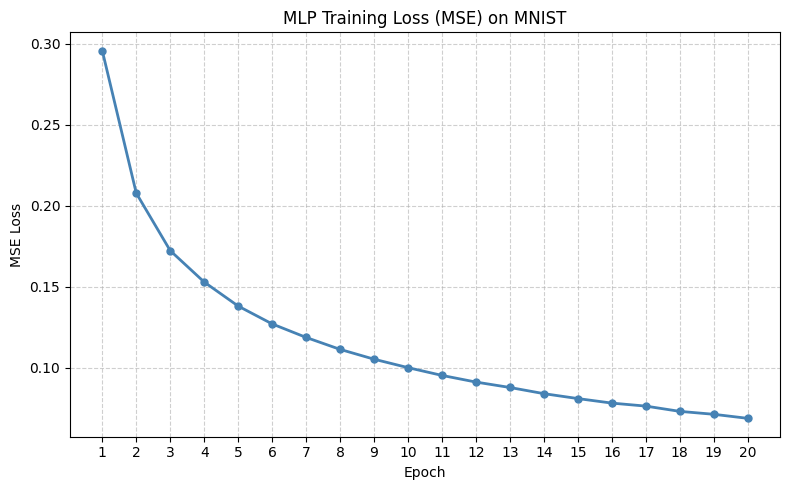

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history,
         marker='o', color='steelblue', linewidth=2, markersize=5)
plt.title("MLP Training Loss (MSE) on MNIST")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

In [13]:
def predict(X, W1, b1, W2, b2, W3, b3):
    _,_,_,_,_,A3 = forward_pass(X, W1,b1,W2,b2,W3,b3)
    return np.argmax(A3, axis=1)

Y_pred_test = predict(X_test, W1,b1,W2,b2,W3,b3)
accuracy = np.mean(Y_pred_test == Y_test) * 100

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 95.54%


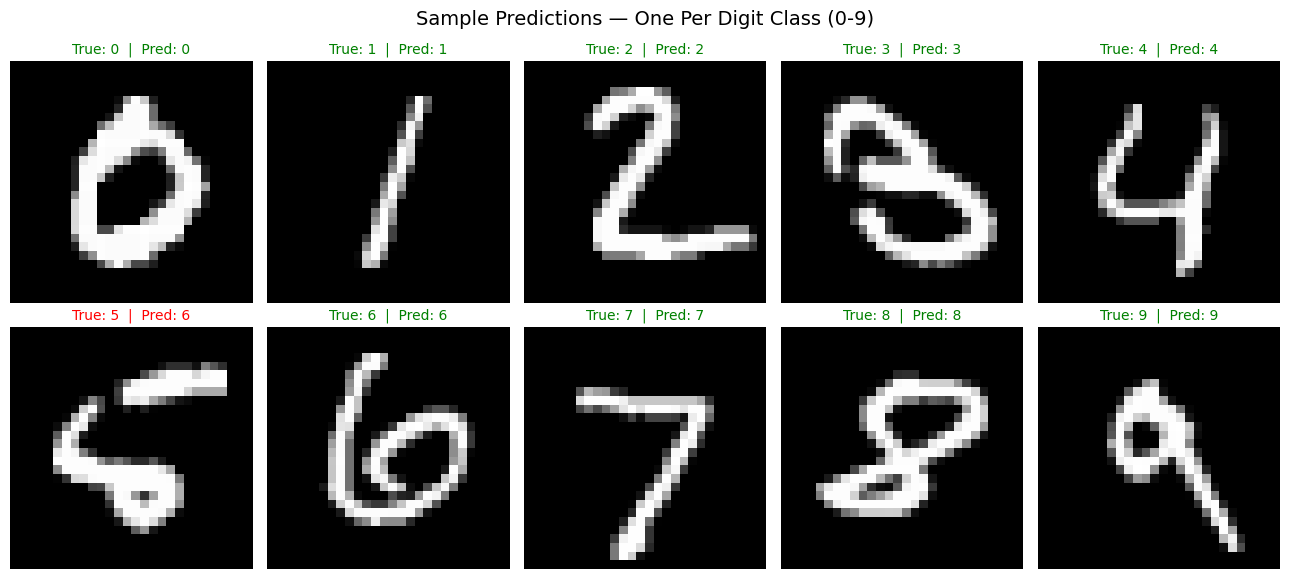

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle("Sample Predictions — One Per Digit Class (0-9)", fontsize=14)

for digit in range(10):
    idx = np.where(Y_test == digit)[0][0]
    image = X_test[idx].reshape(28, 28)
    true_label = Y_test[idx]
    pred_label = Y_pred_test[idx]

    ax = axes[digit // 5][digit % 5]
    ax.imshow(image, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"True: {true_label}  |  Pred: {pred_label}",
                 fontsize=10, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()

In [15]:
print(f"Initial MSE Loss : {loss_history[0]:.4f}")
print(f"Final   MSE Loss : {loss_history[-1]:.4f}")
print(f"Test Accuracy    : {accuracy:.2f}%")

Initial MSE Loss : 0.2957
Final   MSE Loss : 0.0689
Test Accuracy    : 95.54%
